> ### Note on Labs and Assignments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 5: EDA

## Outline

- Univariate analysis (distributions, histograms, counts)
- Bivariate analysis (correlations, scatterplots, group comparisons)
- Reflections and insights

This lab uses the same dataset from **Lab 4**. You will see some overlap in the initial tasks as the data is cleaned.  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## SF Rentals - Business Context 

This dataset represents actual rental listings in the San Francisco housing market, which is known for its high prices, competitive demand, and neighborhood-level variation. In a business context, this type of data could be used by real estate companies, rental platforms, investors, or property managers to better understand pricing trends and market dynamics. The variables provide multiple angles for analysis: pricing (price) can be compared with property features like size (sqft), bedrooms and bathrooms, and whether the listing is a full apartment or just a room; location data (nhood, lat, lon) allows for geographic analysis of rent differences across neighborhoods; and time variables (date, year) help track how the market changes over time. Text fields like title and descr can even be analyzed to understand how listings are marketed. By exploring this dataset, analysts can answer questions such as what factors drive higher rent, which neighborhoods are most expensive, or how prices have changed over time. This kind of analysis is valuable for setting competitive prices, identifying investment opportunities, and helping renters or companies make informed housing decisions.

Note that many of the columns (variables) will be empty.  This is an unfortunate reality in the real world!

Some rentals are apartments, others are for homes, and there may be some other random properties for rent.  Each row represents one rental listing. 

**Source:** Pennington, Kate (2018). Bay Area Craigslist Rental Housing Posts, 2000-2018. Retrieved from [Github](https://github.com/katepennington/historic_bay_area_craigslist_housing_posts/blob/master/clean_2000_2018.csv.zip).

## Data Dictionary

| Variable       | Type       | Description |
|----------------|------------|-------------|
| `post_id`      | Categorical| Unique listing ID |
| `date`         | Numeric    | Listing date (numeric format) |
| `year`         | Integer    | Year of listing |
| `nhood`        | Categorical| Neighborhood |
| `city`         | Categorical| City |
| `county`       | Categorical| County |
| `price`        | Numeric    | Listing price (USD) |
| `beds`         | Numeric    | Number of bedrooms |
| `baths`        | Numeric    | Number of bathrooms |
| `sqft`         | Numeric    | Square footage |
| `room_in_apt`  | Binary     | Indicates whether the rental listing is for an entire apartment (0) or a single room within an apartment (1)|
| `address`      | Categorical| Street address |
| `lat`          | Numeric    | Latitude |
| `lon`          | Numeric    | Longitude |
| `title`        | Text       | Listing title |
| `descr`        | Text       | Listing description |
| `details`      | Text       | Additional details |


## 1. Importing the Data

### Instructions:
- Import the `pandas` library for dataframes.  Then `Matplotlib` and `Seaborn` for data visualization.
- Import data from the rent.csv into a dataframe from the tidytuesday link.
- Use `.info()` and `.head()` to inspect the structure and preview the data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/rent.csv'
df = pd.read_csv(url)

/tmp/ipykernel_600/4027342650.py:2: DtypeWarning: Columns (0: date) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


In [3]:
# Get summary info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200810 entries, 0 to 200809
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   post_id      200810 non-null  str    
 1   date         200797 non-null  object 
 2   year         200796 non-null  float64
 3   nhood        200796 non-null  str    
 4   city         200796 non-null  str    
 5   county       199402 non-null  str    
 6   price        200796 non-null  float64
 7   beds         194188 non-null  float64
 8   baths        42675 non-null   float64
 9   sqft         64679 non-null   float64
 10  room_in_apt  200796 non-null  float64
 11  address      3908 non-null    str    
 12  lat          7651 non-null    float64
 13  lon          4312 non-null    float64
 14  title        198279 non-null  str    
 15  descr        3254 non-null    str    
 16  details      8015 non-null    str    
dtypes: float64(8), object(1), str(8)
memory usage: 26.0+ MB


In [4]:
# Preview the first rows
df.head()

,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
0,pre2013_134138,20050111,2005.0,alameda,alameda,alameda,1250.0,2.0,2.0,NaN,0.0,NaN,NaN,NaN,$1250 / 2br - 2BR/2BA 1145 ALAMEDA DE LAS PU...,NaN,NaN
1,pre2013_135669,20050126,2005.0,alameda,alameda,alameda,1295.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1295 / 2br - Walk the Beach! 1 FREE MONTH + $...,NaN,NaN
2,pre2013_127127,20041017,2004.0,alameda,alameda,alameda,1100.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1100 / 2br - cottage,NaN,NaN
3,pre2013_68671,20120601,2012.0,alameda,alameda,alameda,1425.0,1.0,NaN,735.0,0.0,NaN,NaN,NaN,$1425 / 1br - 735ft² - BEST LOCATION SOUTHSHOR...,NaN,NaN
4,pre2013_127580,20041021,2004.0,alameda,alameda,alameda,890.0,1.0,NaN,NaN,0.0,NaN,NaN,NaN,"$890 / 1br - Classy ""Painted Lady"" VICTORIAN -...",NaN,NaN


## 2. Inspecting Data Quality

### Instructions:
- Check for outliers or invalid data in key numeric variables like `price`, `sqft`, `beds`, or `baths`.  The concept of outliers will be covered more in week 6.  This week we will just look for outliers, but we won't take steps to remove them.     

In [5]:
# Basic summary statistics
df[['price', 'beds', 'baths', 'sqft']].describe()

,price,beds,baths,sqft
count,200796.000000,194188.000000,42675.000000,64679.000000
mean,2135.362746,1.889025,1.679086,1201.827688
std,1427.747903,1.079138,0.690509,5000.217864
min,220.000000,0.000000,1.000000,80.000000
25%,1295.000000,1.000000,1.000000,750.000000
50%,1800.000000,2.000000,2.000000,1000.000000
75%,2505.000000,3.000000,2.000000,1360.000000
max,40000.000000,12.000000,8.000000,900000.000000


### Reflection:
- 2.1 Do any numeric variables contain extreme or unusual values?
- 2.2 Should those outlier values be removed?  Or are they valid rental properties?

### ✍️ Your Response: 🔧
2.1 Yes. `sqft` has the most extreme values: the median is 1,000 sqft, but the max is 900,000 sqft and the standard deviation (about 5,000) is bigger than the mean (about 1,200). A 900,000 sqft rental listed at ＄995 is clearly a typo, and a few other listings show 30,000–57,000 sqft. `price` also has a long right tail: the median is ＄1,800, but the max is ＄40,000 (a 4-bedroom in Napa County), and 56 listings are above ＄20,000. `beds` goes up to 12 and `baths` up to 8, which are rare but possible. Missing data is also a big quality issue: only about 43,000 of the 200,810 rows have `baths` and about 65,000 have `sqft`.

2.2 It depends on the value. Obvious data-entry errors like the 900,000 sqft listing (or a 12-bedroom place renting for about ＄1,400) are not real properties and should be removed or set to missing, because they distort the averages and the correlation between `sqft` and `price`. The high-priced listings (＄20,000–＄40,000) are probably real luxury homes in places like Pacific Heights, Los Altos, or Napa, so I would keep them but analyze them separately or use the median instead of the mean. Since outlier handling is covered in Week 6, I left them in for now.


## 3. Univariate Analysis

Explore individual variables to understand their distributions and frequency.

### Tasks:
- Plot histograms for numeric variables (`price`, `sqft`)
- Plot countplots for categorical variables (`beds`, `nhood`)


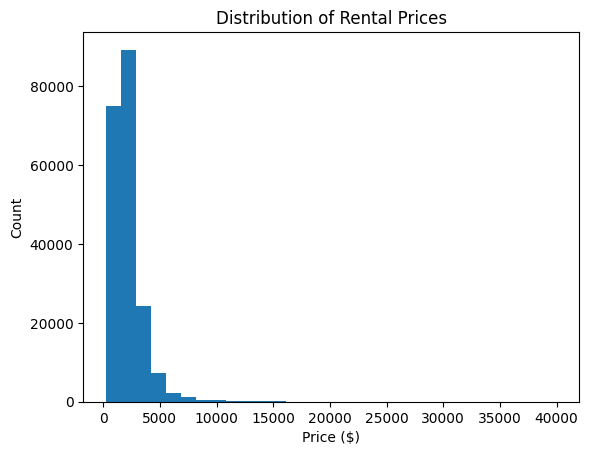

In [6]:
# Histogram: Price
plt.hist(df['price'], bins=30)
plt.title("Distribution of Rental Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

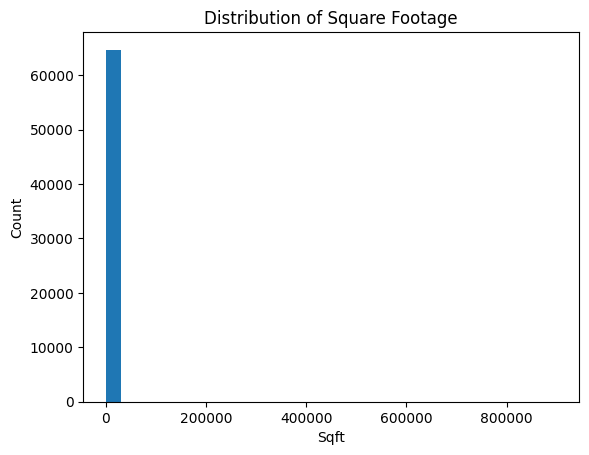

In [7]:
# Histogram: Square Footage
plt.hist(df['sqft'].dropna(), bins=30)
plt.title("Distribution of Square Footage")
plt.xlabel("Sqft")
plt.ylabel("Count")
plt.show()


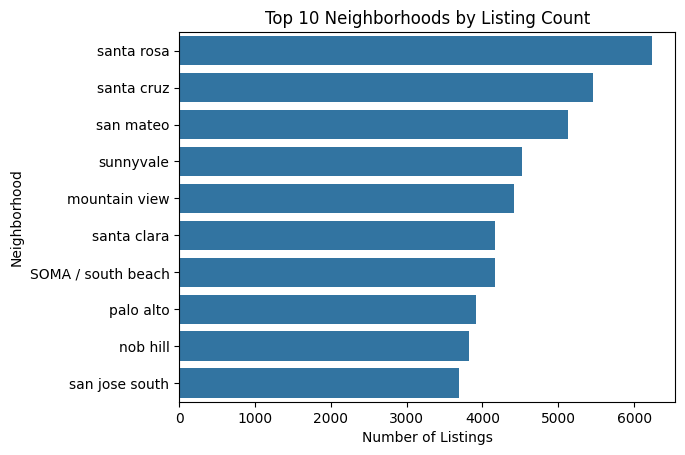

In [8]:
# Bar plot of top 10 neighborhoods by number of listings
top_nhoods = df['nhood'].value_counts().head(10)

sns.barplot(x=top_nhoods.values, y=top_nhoods.index)
plt.title("Top 10 Neighborhoods by Listing Count")
plt.xlabel("Number of Listings")
plt.ylabel("Neighborhood")
plt.show()

### 🔧 Do the following – Part 3

1. Create two new visualizations using different variables than the ones already shown above.

>Suggestions:
- A **histogram** of the `baths` variable
- A **bar chart** showing the **average square footage by number of bathrooms**

> Be sure to label your axes and include a title for each chart.

### Reflection: 

After creating each of the visuals, write 1–2 sentences explaining what you notice in each.


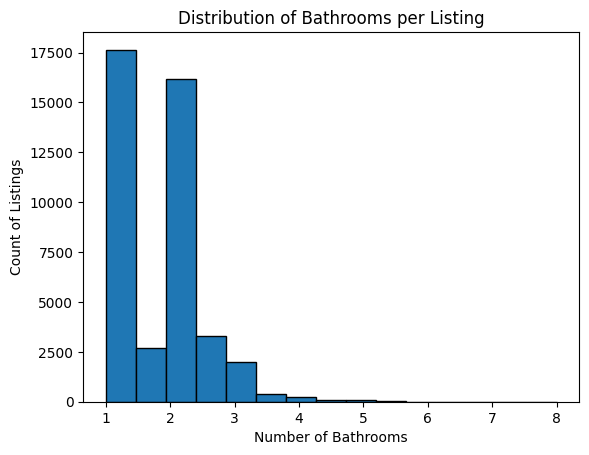

baths
1.0    17644
1.5     2710
2.0    16172
2.5     3309
3.0     2016
3.5      386
4.0      258
4.5       73
5.0       71
5.5       17
6.0       11
6.5        4
7.0        2
7.5        1
8.0        1
Name: count, dtype: int64

In [9]:
# Visual 1 🔧
# Histogram of the number of bathrooms (drop missing values first)
plt.hist(df['baths'].dropna(), bins=15, edgecolor='black')
plt.title("Distribution of Bathrooms per Listing")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Count of Listings")
plt.show()

# Quick counts to back up the chart
df['baths'].value_counts().sort_index()


### ✍️ Visual 1 Response: 🔧
1. Most listings have 1 or 2 bathrooms (about 17,600 and 16,200 listings); together they make up roughly 80% of the listings that report baths. The distribution is right-skewed, with a small tail of large homes that have 3.5 to 8 bathrooms. Also, about 158,000 listings have no bathroom value at all, so this chart only shows about one-fifth of the data.


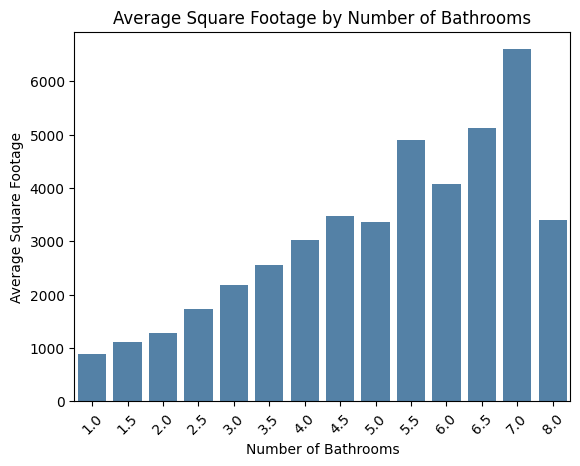

baths
1.0     882.0
1.5    1120.0
2.0    1289.0
2.5    1739.0
3.0    2179.0
3.5    2554.0
4.0    3028.0
4.5    3473.0
5.0    3370.0
5.5    4906.0
6.0    4082.0
6.5    5130.0
7.0    6600.0
8.0    3400.0
Name: sqft, dtype: float64

In [10]:
# Visual 2 🔧
# Average square footage by number of bathrooms
avg_sqft_baths = df.groupby('baths')['sqft'].mean().dropna().sort_index()

sns.barplot(x=avg_sqft_baths.index, y=avg_sqft_baths.values, color='steelblue')
plt.title("Average Square Footage by Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Average Square Footage")
plt.xticks(rotation=45)
plt.show()

avg_sqft_baths.round(0)


### ✍️ Visual 2 Response: 🔧
1. Average square footage rises steadily with the number of bathrooms: about 880 sqft for 1 bath, about 1,290 sqft for 2 baths, and over 3,000 sqft for 4 or more. The bars at 5.5 baths and above jump around because only a handful of listings have that many bathrooms, so those averages aren't reliable.


## 4. Bivariate Analysis

Explore relationships between two variables to understand how features like square footage or bedrooms influence price.


In [11]:
# Correlation matrix
corr_matrix = df[['price', 'beds', 'baths', 'sqft']].corr()
corr_matrix


,price,beds,baths,sqft
price,1.000000,0.450096,0.433553,0.074310
beds,0.450096,1.000000,0.651835,0.707235
baths,0.433553,0.651835,1.000000,0.645372
sqft,0.074310,0.707235,0.645372,1.000000


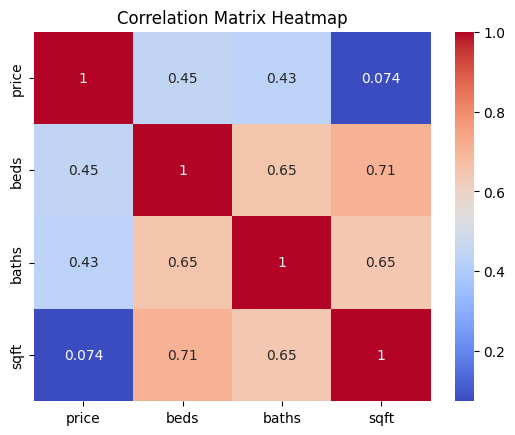

In [12]:
# Heatmap of correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()

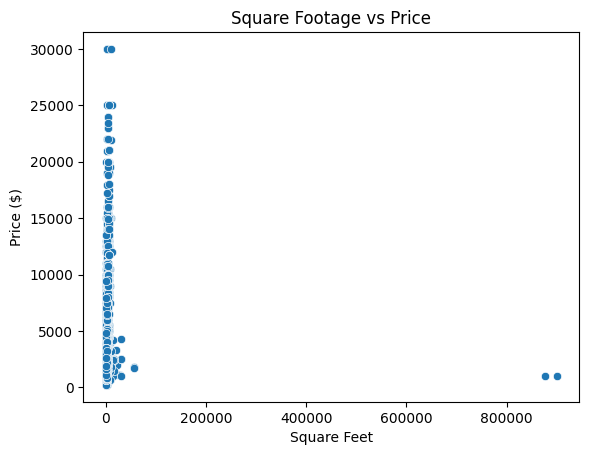

In [13]:
# Scatterplot: Square Footage vs Price
sns.scatterplot(x='sqft', y='price', data=df)
plt.title("Square Footage vs Price")
plt.xlabel("Square Feet")
plt.ylabel("Price ($)")
plt.show()

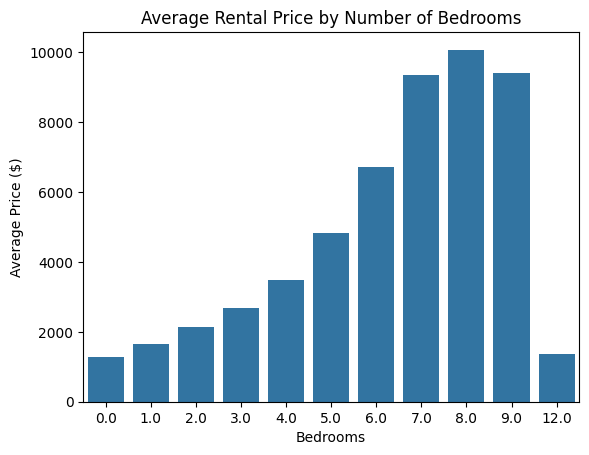

In [14]:
# Average price by number of bedrooms
avg_price_beds = df.groupby('beds')['price'].mean().sort_index()
sns.barplot(x=avg_price_beds.index, y=avg_price_beds.values)
plt.title("Average Rental Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price ($)")
plt.show()

### 🔧 Do the following – Part 4

- 4.1 Create a scatterplot of `baths` vs `price`.  
- 4.2 Group by `year` and plot the average price over time.

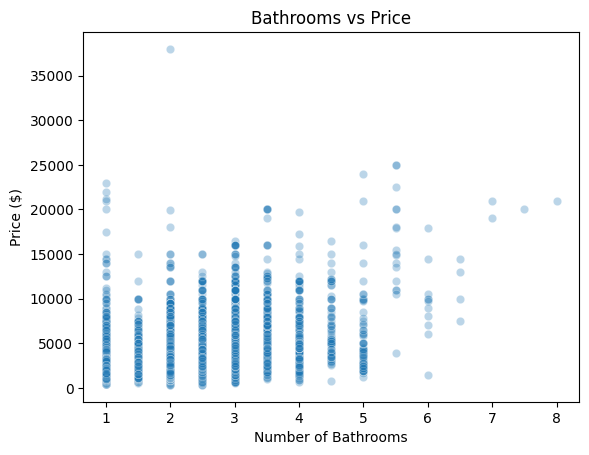

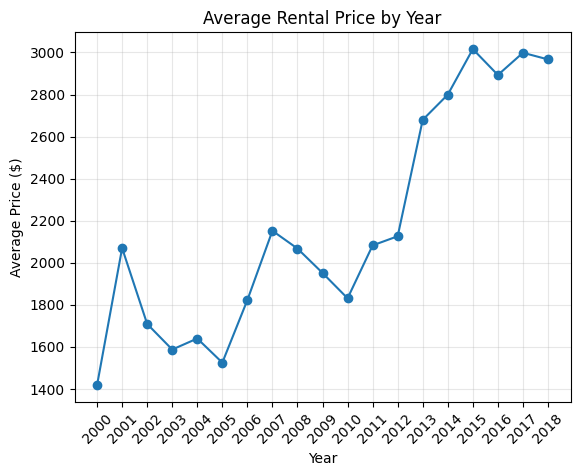

year
2000.0    1419.0
2001.0    2070.0
2002.0    1709.0
2003.0    1588.0
2004.0    1640.0
2005.0    1525.0
2006.0    1823.0
2007.0    2152.0
2008.0    2068.0
2009.0    1952.0
2010.0    1831.0
2011.0    2083.0
2012.0    2126.0
2013.0    2680.0
2014.0    2800.0
2015.0    3016.0
2016.0    2893.0
2017.0    2999.0
2018.0    2967.0
Name: price, dtype: float64

In [15]:
# Add code here 🔧

# 4.1 Scatterplot: Bathrooms vs Price
sns.scatterplot(x='baths', y='price', data=df, alpha=0.3)
plt.title("Bathrooms vs Price")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price ($)")
plt.show()

# 4.2 Average price over time
avg_price_year = df.groupby('year')['price'].mean().sort_index()

plt.plot(avg_price_year.index, avg_price_year.values, marker='o')
plt.title("Average Rental Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Price ($)")
plt.xticks(avg_price_year.index, avg_price_year.index.astype(int), rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

avg_price_year.round(0)


### Reflection:
4.1 What trends or outliers do you see?

### ✍️ Your Response: 🔧
4.1 The scatterplot shows a positive trend: listings with more bathrooms tend to rent for more (average price is about ＄1,860 for 1 bath, ＄2,540 for 2 baths, and ＄3,750 for 3 baths). But the spread within each bathroom count is very wide, and there are clear outliers, like 1- and 2-bath listings priced above ＄20,000. The line chart shows rents staying mostly between about ＄1,500 and ＄2,150 from 2002 to 2012, then climbing sharply to about ＄3,000 by 2015 and flattening out through 2018. The 2000 and 2001 points are based on very few listings (23 and 735), so the spike in 2001 shouldn't be trusted.


## 🔧  Part 5: Reflection

Answer the following questions in the markdown cell below (no more than a few sentences per question required)

- 5.1 Which variables are most strongly correlated with rental price?
- 5.2 Are there patterns in how size (sqft) or number of bedrooms affects price?
- 5.3 Which neighborhoods or years show the highest prices?
- 5.4 What other visualizations or groupings might improve this analysis?

Use this section to summarize insights from both Labs 4 and 5.

### ✍️ Your Response: 🔧
5.1 `beds` (r ≈ 0.45) and `baths` (r ≈ 0.43) have the strongest correlation with price. They are only moderate relationships, so bedroom and bathroom count explain part of the price but not all of it. Surprisingly, `sqft` barely correlates with price (r ≈ 0.07), but that is mostly because of the extreme typo values (like 900,000 sqft) and the fact that only about a third of listings report square footage.

5.2 Yes. Average price rises with each added bedroom, from about ＄1,280 for studios (0 beds) to ＄2,150 for 2 beds, ＄3,490 for 4 beds, and over ＄9,000 for 7–8 beds. The pattern breaks down at 9–12 bedrooms because there are only a few of those listings and some look like errors. Square footage is strongly tied to bedrooms (r ≈ 0.71) and baths (r ≈ 0.65), so bigger places generally cost more, but the sqft-vs-price scatterplot is squeezed by the outliers. It would need to be cleaned before the size effect shows up clearly.

5.3 Among neighborhoods with at least 500 listings, Tiburon/Belvedere (about ＄4,270 average), the Financial District (about ＄3,960), Los Altos (about ＄3,600), SOMA/South Beach (about ＄3,590), and Pacific Heights (about ＄3,490) have the highest average rents. By year, the highest average prices were in 2015–2018 (about ＄2,900–＄3,000), roughly double the mid-2000s level. In Lab 4 we also saw that the listing counts are very uneven across years (for example, about 42,000 listings in 2004 compared with fewer than 2,500 in 2017), so the yearly averages are more reliable in some years than others.

5.4 A few things would improve this analysis:
- Price per square foot by neighborhood, to compare value instead of just total rent
- Boxplots of price by neighborhood or by `room_in_apt` (whole apartment vs. single room), which would show the spread and outliers better than averages
- The same analysis rerun after removing or capping outliers, with only complete rows for `sqft` and `baths`
- A map using `lat` and `lon` colored by price, to show geographic patterns
- Median price by year, split by city (San Francisco vs. San Jose vs. Oakland), to see whether all areas rose at the same rate


## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [ ]:
!jupyter nbconvert --to html "lab_05_eda.ipynb"